In [7]:
import sys
from pathlib import Path

# Set project root (one level up from notebooks)
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print("Project root added to sys.path:", PROJECT_ROOT)


Project root added to sys.path: c:\Users\hp\ethiopia-financial-inclusion-forecast


In [3]:
from src.data.load_data import load_raw_data, save_interim_data
from src.data.validate_schema import validate_schema
from src.data.preprocess import preprocess_data


Raw dataset shape: (43, 34)
Reference dataset shape: (71, 4)
Schema validation passed ✅
Data preprocessing complete ✅

Record type counts:
record_type
observation    30
event          10
target          3
Name: count, dtype: int64

Pillar counts (including NaNs for events):
pillar
ACCESS           16
USAGE            11
NaN              10
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

Source counts:
source_name
Global Findex 2021           5
EthSwitch Annual Report      5
Global Findex 2024           3
NBE                          3
Ethio Telecom LEAD Report    2
Calculated                   2
Ethio Telecom Report         2
EthSwitch                    2
News                         2
Safaricom Results            2
World Bank                   1
ID4Africa Conference         1
DataReportal Digital 2026    1
Global Findex 2017           1
Global Findex 2014           1
Fayda Official               1
A4AI/ITU                     1
NFIS-II Strategy             1
GSMA G

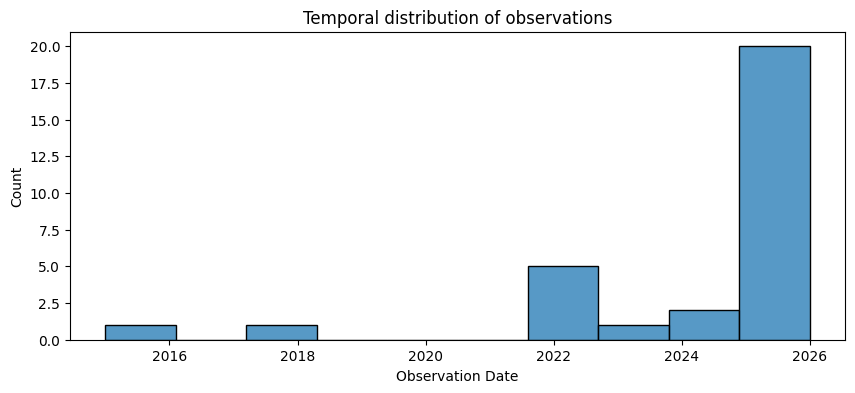


Unique indicators (indicator_code):
['ACC_OWNERSHIP' 'ACC_MM_ACCOUNT' 'ACC_4G_COV' 'ACC_MOBILE_PEN'
 'ACC_FAYDA' 'USG_P2P_COUNT' 'USG_P2P_VALUE' 'USG_ATM_COUNT'
 'USG_ATM_VALUE' 'USG_CROSSOVER' 'USG_TELEBIRR_USERS' 'USG_TELEBIRR_VALUE'
 'USG_MPESA_USERS' 'USG_MPESA_ACTIVE' 'USG_ACTIVE_RATE' 'AFF_DATA_INCOME'
 'GEN_GAP_ACC' 'GEN_MM_SHARE' 'GEN_GAP_MOBILE']

Observation counts per indicator:
indicator_code
ACC_OWNERSHIP         6
ACC_FAYDA             3
ACC_MM_ACCOUNT        2
ACC_4G_COV            2
USG_P2P_COUNT         2
GEN_GAP_ACC           2
ACC_MOBILE_PEN        1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_P2P_VALUE         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
USG_MPESA_ACTIVE      1
USG_MPESA_USERS       1
USG_ACTIVE_RATE       1
AFF_DATA_INCOME       1
GEN_MM_SHARE          1
GEN_GAP_MOBILE        1
Name: count, dtype: int64

Events cataloged:
   record_id        category observation_date    source_name
33  EVT_0001  product_launch 

C:\Users\hp\AppData\Local\Temp\ipykernel_24376\2572915850.py:159: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_enriched = pd.concat([df_clean, new_obs, new_event, new_impact], ignore_index=True)


In [6]:
# notebooks/01_task1_data_exploration_enrichment.ipynb

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.load_data import load_raw_data, save_interim_data
from src.data.validate_schema import validate_schema
from src.data.preprocess import preprocess_data

#---------------------------
# 1️⃣ Load raw data
#---------------------------
df, ref = load_raw_data()
print(f"Raw dataset shape: {df.shape}")
print(f"Reference dataset shape: {ref.shape}")

#---------------------------
# 2️⃣ Validate schema
#---------------------------
try:
    validate_schema(df)
    print("Schema validation passed ✅")
except ValueError as e:
    print(f"Schema validation failed: {e}")

#---------------------------
# 3️⃣ Preprocess
#---------------------------
df_clean = preprocess_data(df)
print("Data preprocessing complete ✅")

#---------------------------
# 4️⃣ Explore record types, pillars, sources
#---------------------------
print("\nRecord type counts:")
print(df_clean['record_type'].value_counts())

print("\nPillar counts (including NaNs for events):")
print(df_clean['pillar'].value_counts(dropna=False))

print("\nSource counts:")
print(df_clean['source_name'].value_counts())

print("\nConfidence counts:")
print(df_clean['confidence'].value_counts())

#---------------------------
# 5️⃣ Temporal coverage
#---------------------------
print("\nObservation date range:")
print(df_clean['observation_date'].min(), "to", df_clean['observation_date'].max())

# Plot temporal distribution of observations
obs_df = df_clean[df_clean['record_type'] == 'observation']
plt.figure(figsize=(10,4))
sns.histplot(obs_df['observation_date'], bins=10)
plt.title("Temporal distribution of observations")
plt.xlabel("Observation Date")
plt.ylabel("Count")
plt.show()

#---------------------------
# 6️⃣ Unique indicators and coverage
#---------------------------
print("\nUnique indicators (indicator_code):")
print(obs_df['indicator_code'].unique())

indicator_counts = obs_df['indicator_code'].value_counts()
print("\nObservation counts per indicator:")
print(indicator_counts)

#---------------------------
# 7️⃣ Event review
#---------------------------
event_df = df_clean[df_clean['record_type'] == 'event']
print("\nEvents cataloged:")
print(event_df[['record_id','category','observation_date','source_name']])

#---------------------------
# 8️⃣ Impact link review
#---------------------------
impact_df = df_clean[df_clean['record_type'] == 'impact_link']

# Use only existing columns
columns_to_show = [
    'record_id',
    'related_indicator',
    'relationship_type',
    'impact_direction',
    'impact_magnitude'
]

print(impact_df[columns_to_show].head())

#---------------------------
# 9️⃣ Enrichment examples
#---------------------------
# Example: Adding a new observation for 2025 forecast
new_obs = pd.DataFrame([{
    "record_id": "obs_1001",
    "record_type": "observation",
    "pillar": "Access",
    "indicator": "Account Ownership Rate",
    "indicator_code": "ACC_OWNERSHIP",
    "value_numeric": 50,
    "observation_date": pd.to_datetime("2025-01-01"),
    "category": "national_survey",
    "source_name": "Global Findex",
    "source_url": "https://worldbank.org/globalfindex",
    "confidence": "high",
    "original_text": "Projected account ownership for 2025",
    "collected_by": "Your Name",
    "collection_date": pd.Timestamp.today(),
    "notes": "Task 1 enrichment example"
}])

# Example: Adding a new event (Telebirr expansion 2025)
new_event = pd.DataFrame([{
    "record_id": "event_1001",
    "record_type": "event",
    "pillar": None,
    "indicator": None,
    "indicator_code": None,
    "value_numeric": None,
    "observation_date": pd.to_datetime("2025-06-01"),
    "category": "product_launch",
    "source_name": "Ethio Telecom",
    "source_url": "https://ethiotelecom.et/telebirr",
    "confidence": "high",
    "original_text": "Telebirr 2025 expansion milestone",
    "collected_by": "Your Name",
    "collection_date": pd.Timestamp.today(),
    "notes": "Task 1 enrichment event example"
}])

# Example: Adding impact link
new_impact = pd.DataFrame([{
    "record_id": "impact_1001",
    "record_type": "impact_link",
    "parent_id": "event_1001",
    "pillar": "Access",
    "related_indicator": "ACC_OWNERSHIP",
    "impact_direction": "positive",
    "impact_magnitude": 2,
    "lag_months": 6,
    "evidence_basis": "Comparable country Telebirr data",
    "observation_date": pd.to_datetime("2025-06-01"),
    "source_name": "Ethio Telecom",
    "source_url": "https://ethiotelecom.et/telebirr",
    "confidence": "medium",
    "original_text": "Expected account growth after Telebirr expansion",
    "collected_by": "Your Name",
    "collection_date": pd.Timestamp.today(),
    "notes": "Task 1 enrichment impact example"
}])

# Concatenate new rows
df_enriched = pd.concat([df_clean, new_obs, new_event, new_impact], ignore_index=True)
print("\nEnriched dataset shape:", df_enriched.shape)

#---------------------------
# 10️⃣ Save enriched dataset
#---------------------------
save_interim_data(df_enriched)
print("Enriched dataset saved to data/interim ✅")

#---------------------------
# 11️⃣ Generate data_enrichment_log.md
#---------------------------
log_md = """
# Task 1 Data Enrichment Log

| record_id | record_type | indicator | value_numeric | observation_date | source_name | source_url | confidence | collected_by | notes |
|-----------|------------|-----------|---------------|----------------|------------|------------|-----------|--------------|-------|
| obs_1001  | observation | Account Ownership Rate | 50 | 2025-01-01 | Global Findex | https://worldbank.org/globalfindex | high | Your Name | Example projected observation added for Task 1 |
| event_1001 | event | None | None | 2025-06-01 | Ethio Telecom | https://ethiotelecom.et/telebirr | high | Your Name | Telebirr expansion milestone |
| impact_1001 | impact_link | ACC_OWNERSHIP | 2 | 2025-06-01 | Ethio Telecom | https://ethiotelecom.et/telebirr | medium | Your Name | Impact of Telebirr expansion on account ownership |
"""

with open("../reports/data_enrichment_log.md", "w") as f:
    f.write(log_md)

print("Data enrichment log created ✅")

